In [1]:
# Install required packages (if needed)
# !pip3 install pandas numpy matplotlib seaborn scikit-learn tqdm requests -q

# Ollama API setup and imports
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, classification_report
import numpy as np
from datetime import datetime
import re

print("✓ Libraries imported successfully")
print("✓ Ollama will be used for LLM inference (local)")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Ollama API configuration
OLLAMA_API_URL = "http://localhost:11434/api/generate"

✓ Libraries imported successfully
✓ Ollama will be used for LLM inference (local)


## 1. Load Dataset

In [2]:
# Load the 100% agreement dataset (highest quality)
data_path = "../../../Startified Data PMP/Processed Data/processed_data.csv"

df = pd.read_csv(data_path)
df.rename(columns={"sentiment": "true_risk"}, inplace=True)
df.rename(columns={"sentences": "sentence"}, inplace=True)

print(f"Dataset loaded: {len(df)} sentences")

# Display sample
print("\n" + "=" * 80)
print("Sample sentences:")
print("=" * 80)
display(df.sample(5, random_state=42))

Dataset loaded: 210 sentences

Sample sentences:


,sentence,true_risk,word_count,char_length
30,Tallink Silja attributes the significant drop ...,negative,46,267
172,"ADP News - Feb 13 , 2009 - Finnish retailer Ke...",negative,43,207
84,20 October 2010 - Finnish environmental manage...,negative,43,237
199,"Finnair 's Tallinn-based subsidiary , Aero AS ...",negative,31,178
60,MegaFon 's subscriber base increased 16.1 % in...,positive,50,246


## 2. Tree-of-Thought Prompt Design

**Multi-Path Reasoning**:
- Path 1: Consider "positive" hypothesis
- Path 2: Consider "negative" hypothesis  
- Path 3: Consider "neutral" hypothesis
- Evaluation: Score each path's evidence strength
- Selection: Choose the most supported hypothesis

In [3]:
def create_tot_prompt(sentence):
    """
    Creates a Tree-of-Thought prompt with multi-path exploration.
    """
    prompt = f"""You are a financial risk assessment expert. 

Financial Statement:
"{sentence}"

Task: Evaluate the risk of the following statement from an investor's perspective.

---
PATH 1: Hypothesis = POSITIVE
Opportunity signals that reduce investment risk, aligning with scenarios like 
- revenue growth
- profit increase
- market expansion
- strong performance

PATH 2: Hypothesis = NEGATIVE
Threat signals that increase investment risk, aligning with scenarios like
- losses
- declining sales
- operational challenges
- market difficulties

PATH 3: Hypothesis = NEUTRAL
Informational content with no or risk implications, routine announcements, balanced statements.

---
FINAL DECISION:
Based on evaluating all three paths, select the hypothesis with the strongest evidence.

Provide your final answer in this exact JSON format:
{{
    "risk": "positive/negative/neutral",
    "confidence": 0.0-1.0,
    "rationale": "Explanation of why this hypothesis was selected over the others"
    
}}
"""
    return prompt


# Test prompt

print("=" * 80)
print("TREE-OF-THOUGHT PROMPT EXAMPLE")
print("=" * 80)
print(create_tot_prompt(df["sentence"].iloc[0]))

TREE-OF-THOUGHT PROMPT EXAMPLE
You are a financial risk assessment expert. 

Financial Statement:
"Supported Nokia phones include : N96 , N95-8GB , N95 , N93-N931 , N92 , N85 , N82 , N81 , N80 , N79 , N78 , N77 , N76 , N75 , N73 , N72 , N71 , E90 , E71 , E70 , E66 , E65 , E62 , E61-E61i , E60 , E51 , E50 , Touch Xpress 5800 , 6220 Classic , 6210 Navigator , 6120 Classic , 6110 Navigator , 5700 , 5500 , 5320XM ."

Task: Evaluate the risk of the following statement from an investor's perspective.

---
PATH 1: Hypothesis = POSITIVE
Opportunity signals that reduce investment risk, aligning with scenarios like 
- revenue growth
- profit increase
- market expansion
- strong performance

PATH 2: Hypothesis = NEGATIVE
Threat signals that increase investment risk, aligning with scenarios like
- losses
- declining sales
- operational challenges
- market difficulties

PATH 3: Hypothesis = NEUTRAL
Informational content with no or risk implications, routine announcements, balanced statements.

---


## 3. Model Inference Functions

In [4]:
def call_ollama(prompt, model_name, temperature=0.0):
    """Call Ollama API for LLM inference"""
    max_retries = 3
    last_error = None
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                json={
                    "model": model_name,
                    "prompt": prompt,
                    "stream": False,
                    "temperature": temperature,
                },
                timeout=150,
            )
            
            if response.status_code == 200:
                result = response.json()
                return result.get("response", "")
            else:
                last_error = f"HTTP {response.status_code}"
                
        except Exception as e:
            last_error = str(e)
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
                continue
            return None
    
    return None


import json
import re

REQUIRED_KEYS = {"risk", "confidence", "rationale"}
VALID_RISK_VALUES = {"positive", "negative", "neutral"}

def parse_response(response_text):
    """Parse JSON response from model"""
    try:
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "```" in response_text:
            json_str = response_text.split("```")[1].strip()
        else:
            json_str = response_text.strip()

        # Find the first { ... } block in case there's leading text
        start = json_str.find("{")
        end = json_str.rfind("}") + 1
        if start != -1 and end > start:
            json_str = json_str[start:end]

        result = json.loads(json_str)

        # If model returned a list, take the first element
        if isinstance(result, list):
            result = result[0]

        # Validate only the 3 required keys exist and risk is valid
        if not REQUIRED_KEYS.issubset(result.keys()):
            raise ValueError(f"Missing required keys. Got: {set(result.keys())}")
        if result["risk"] not in VALID_RISK_VALUES:
            raise ValueError(f"Invalid risk value: {result['risk']}")

        # Return only the 3 keys, stripping any extra fields like "company"
        return {k: result[k] for k in REQUIRED_KEYS}

    except Exception as e:
        print("Parse error: {}".format(str(e)[:100]))
        print("Raw response was:\n{}".format(response_text))
        response_lower = response_text.lower() if response_text else ""
        if "positive" in response_lower and "negative" not in response_lower:
            return {"risk": "positive", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "negative" in response_lower:
            return {"risk": "negative", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "neutral" in response_lower:
            return {"risk": "neutral", "confidence": 0.5, "rationale": "Parsed from text"}
        return None

print("✓ Inference functions defined")

✓ Inference functions defined


In [5]:
# Test API calls with a sample sentence
test_sentence = df["sentence"].iloc[0]
test_prompt = create_tot_prompt(test_sentence)

print("=" * 80)
print("Testing llama3.1:8b...")
print("=" * 80)
llama3_response = call_ollama(test_prompt, model_name="llama3.1:8b")
if llama3_response:
    print(f"✓ Response received (length: {len(llama3_response)})")
    print(f"Response: {llama3_response[:500]}")
    try:
        parsed = json.loads(llama3_response)
        print(f"✓ Parsed successfully: {parsed}")
    except Exception as e:
        print(f"✗ Failed to parse response as JSON: {e}")
else:
    print("✗ llama3.1:8b call failed - no response received")

Testing llama3.1:8b...
✓ Response received (length: 2322)
Response: Here is my evaluation:

**Financial Statement Analysis**

The provided financial statement appears to be a list of supported Nokia phones, which could be related to product offerings or sales data. As an investor, I would evaluate this information as follows:

**PATH 1: Hypothesis = POSITIVE**

Opportunity signals that reduce investment risk:
- Revenue growth: The extensive list of supported phones suggests a large and diverse portfolio, potentially indicating strong revenue growth.
- Profit inc
✗ Failed to parse response as JSON: Expecting value: line 1 column 1 (char 0)


In [6]:
print("\n" + "=" * 80)
print("Testing qwen3:8b...")
print("=" * 80)
qwen3_response = call_ollama(test_prompt, model_name="qwen3:8b")
if qwen3_response:
    print(f"✓ Response received (length: {len(qwen3_response)})")
    print(f"Response: {qwen3_response[:500]}")
    parsed = parse_response(qwen3_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ qwen3:8b call failed - no response received")


Testing qwen3:8b...
✓ Response received (length: 459)
Response: {
    "risk": "neutral",
    "confidence": 0.95,
    "rationale": "The statement provides informational content about supported Nokia phone models without indicating financial performance trends, risks, or opportunities. There are no explicit signals of revenue growth, market expansion, losses, or operational challenges. The list appears to be a routine technical announcement rather than a risk-related statement, aligning with the 'neutral' hypothesis."
}
✓ Parsed successfully: {'rationale': "The statement provides informational content about supported Nokia phone models without indicating financial performance trends, risks, or opportunities. There are no explicit signals of revenue growth, market expansion, losses, or operational challenges. The list appears to be a routine technical announcement rather than a risk-related statement, aligning with the 'neutral' hypothesis.", 'risk': 'neutral', 'confidence': 0.95}


In [7]:
print("\n" + "=" * 80)
print("Testing deepseek-r1:8b...")
print("=" * 80)
deepseek_response = call_ollama(test_prompt, model_name="deepseek-r1:8b")
if deepseek_response:
    print(f"✓ Response received (length: {len(deepseek_response)})")
    print(f"Response: {deepseek_response[:500]}")
    parsed = parse_response(deepseek_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ deepseek-r1:8b call failed - no response received")


Testing deepseek-r1:8b...
✓ Response received (length: 488)
Response: ```json
{
    "risk": "neutral",
    "confidence": 0.95,
    "rationale": "The provided statement is a simple list of supported Nokia phone models without any accompanying financial, market, or performance indicators. It lacks any explicit or implicit signals about revenue growth, profit changes, market expansion, operational challenges, or losses. This type of informational content aligns with routine announcements and does not inherently imply investment risk or opportunity."
}
```
✓ Parsed successfully: {'rationale': 'The provided statement is a simple list of supported Nokia phone models without any accompanying financial, market, or performance indicators. It lacks any explicit or implicit signals about revenue growth, profit changes, market expansion, operational challenges, or losses. This type of informational content aligns with routine announcements and does not inherently imply investment risk or opportun

## 4. Run Experiments

In [8]:

def run_tot_experiment(df, model_name, exp_id):
    print(f"Running {exp_id}: {model_name} (ToT)...")
    results = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{exp_id} Progress"):
        prompt = create_tot_prompt(row["sentence"])
        response = call_ollama(prompt, model_name)
        
        if response:
            parsed = parse_response(response)
            results.append({
                "sentence": row["sentence"],
                "true_risk": row["true_risk"],
                "predicted_risk": parsed.get("risk", "error") if parsed else "error",
                "confidence": parsed.get("confidence", 0) if parsed else 0,
                "rationale": parsed.get("rationale", "Parse error") if parsed else "Parse error"
            })
        time.sleep(0.1)
    return pd.DataFrame(results)

In [9]:
# Execution of R10
r10_df = run_tot_experiment(df, "llama3.1:8b", "R10")

Running R10: llama3.1:8b (ToT)...


R10 Progress:   6%|▌         | 13/210 [04:04<53:13, 16.21s/it]  

Parse error: Expecting value: line 5 column 1 (char 67)
Raw response was:
Based on the financial statement, I would select the following:

{
    "risk": "negative",
    "confidence": 0.8,
    "rationale": 
The company expects full-year sales to contract by 25%, which is a threat signal that increases investment risk (PATH 2). This contraction in sales volume will likely lead to lower operating profit margins, as the company cannot offset the revenue loss with cost cuts alone. While the gross margin is expected to stay healthy, this is not enough to offset the decline in sales. Furthermore, there is no mention of any efforts to mitigate or address the sales contraction, which suggests that the company may be facing significant operational challenges. This leads me to conclude that the negative hypothesis has the strongest evidence, with a confidence level of 0.8.
}


R10 Progress:   9%|▊         | 18/210 [05:32<54:38, 17.07s/it]  

Parse error: Expecting value: line 5 column 3 (char 63)
Raw response was:
After evaluating the given financial statement, I conclude:

```
{
  "risk": "negative",
  "confidence": 0.7,
  "rationale": 
  The provided statement is a list of countries from which the company receives customers. From an investor's perspective, this information does not directly indicate revenue growth, profit increase, or market expansion (PATH 1). It also does not suggest losses, declining sales, operational challenges, or market difficulties (PATH 2) that would raise significant red flags. However, it is a broad geographical distribution which may introduce logistical and operational complexities (e.g., managing diverse customer needs, time zones, languages), potentially increasing the risk of misunderstandings or miscommunications with customers across different regions. This neutral to slightly negative implication leans towards PATH 3 but since there's no clear evidence of market expansion or strong per

...

R10 Progress:  85%|████████▍ | 178/210 [51:49<08:03, 15.10s/it]

Parse error: Invalid risk value: positive/negative
Raw response was:
Here's my evaluation:

**
Financial Statement Analysis
**

After analyzing the statement, I conclude that:

```
{
  "risk": "positive/negative",
  "confidence": 0.8,
  "rationale": "The financial statement indicates a significant decline in net income from EUR 29.3 million to a loss of EUR 81.5 million, indicating a negative trend for the company. While this may be an isolated incident or a response to external market conditions, it suggests increased risk for investors."
}
```

Here's my reasoning:

* PATH 1 (Positive): There are no indicators of revenue growth, profit increase, market expansion, or strong performance in the statement.
* PATH 2 (Negative): The statement clearly indicates a significant decline in net income, which is a threat signal that increases investment risk. This aligns with scenarios like losses and operational challenges.
* PATH 3 (Neutral): While the statement provides some routine informatio

R10 Progress:  98%|█████████▊| 205/210 [59:13<01:11, 14.25s/it]

Parse error: Expecting value: line 5 column 1 (char 61)
Raw response was:
Here's my evaluation:

{
  "risk": "negative",
  "confidence": 0.8,
  "rationale": 
Scanfil Oyj reported a decline in sales, which is a threat signal that increases investment risk (PATH 2: Hypothesis = NEGATIVE). This statement does not mention revenue growth, profit increase, market expansion, or strong performance, which are all opportunity signals that would reduce investment risk (PATH 1: Hypothesis = POSITIVE). The decline in sales also implies operational challenges and market difficulties, further supporting the negative hypothesis. While some routine announcements can be neutral, this statement has a clear implication of declining performance, making PATH 3 (Hypothesis = NEUTRAL) less likely.
}


R10 Progress: 100%|██████████| 210/210 [1:00:45<00:00, 17.36s/it]


In [10]:
print("\nR10 Sample Results:")
print("\nTrue Risk Counts:")
print(r10_df['true_risk'].value_counts())
print("\nPredicted Risk Counts:")
print(r10_df['predicted_risk'].value_counts())


R10 Sample Results:

True Risk Counts:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted Risk Counts:
predicted_risk
negative    119
positive     73
neutral      18
Name: count, dtype: int64


In [13]:
#Execution of R11
r11_df = run_tot_experiment(df, "qwen3:8b", "R11")

Running R11: qwen3:8b (ToT)...


R11 Progress: 100%|██████████| 210/210 [2:25:59<00:00, 41.71s/it]  


In [14]:
print("\nR11 Sample Results:")
print("\nTrue Risk Counts:")
print(r11_df['true_risk'].value_counts())
print("\nPredicted Risk Counts:")
print(r11_df['predicted_risk'].value_counts())


R11 Sample Results:

True Risk Counts:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted Risk Counts:
predicted_risk
positive    79
negative    66
neutral     65
Name: count, dtype: int64


In [15]:
# Execution of R12
r12_df = run_tot_experiment(df, "deepseek-r1:8b", "R12")

Running R12: deepseek-r1:8b (ToT)...


R12 Progress: 100%|██████████| 210/210 [2:35:25<00:00, 44.41s/it]  


In [16]:
print("\nR12 Sample Results:")
print("\nTrue Risk Counts:")
print(r12_df['true_risk'].value_counts())
print("\nPredicted Risk Counts:")
print(r12_df['predicted_risk'].value_counts())


R12 Sample Results:

True Risk Counts:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted Risk Counts:
predicted_risk
positive    81
negative    71
neutral     58
Name: count, dtype: int64


## 5. Calculate Metrics

In [17]:
# Calculate metrics for all experiments
def calculate_metrics(df, exp_name):
    """Calculate all evaluation metrics"""
    if df.empty or "predicted_risk" not in df.columns:
        print(f"⚠️ Warning: {exp_name} has no valid predictions!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": 0,
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )
    
    valid_df = df[
        df["predicted_risk"].isin(["positive", "negative", "neutral"])
    ].copy()
    if valid_df.empty:
        print(f"⚠️ Warning: {exp_name} has no valid predictions after filtering!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": len(df),
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )
    y_true = valid_df["true_risk"]
    y_pred = valid_df["predicted_risk"]
    
    metrics = {
        "Experiment": exp_name,
        "Total Samples": len(df),
        "Valid Predictions": len(valid_df),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro"),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    
    labels = ["positive", "negative", "neutral"]
    precision_per_class = precision_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    recall_per_class = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    f1_per_class = f1_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )

    for i, label in enumerate(labels):
        metrics[f"{label.capitalize()}_Precision"] = precision_per_class[i]
        metrics[f"{label.capitalize()}_Recall"] = recall_per_class[i]
        metrics[f"{label.capitalize()}_F1"] = f1_per_class[i]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return metrics, cm, valid_df


# Calculate metrics for all experiments
r10_metrics, r10_cm, r10_valid = calculate_metrics(r10_df, "R10: Llama3.1:8b (ToT)")
r11_metrics, r11_cm, r11_valid = calculate_metrics(r11_df, "R11: Qwen3:8b (ToT)")
r12_metrics, r12_cm, r12_valid = calculate_metrics(r12_df, "R12: DeepSeek-R1:8b (ToT)")

metrics_df = pd.DataFrame([r10_metrics, r11_metrics, r12_metrics])
print("\n" + "=" * 80)
print("CHAIN-OF-THOUGHT PERFORMANCE COMPARISON")
print("=" * 80)
display(
    metrics_df[
        ["Experiment", "Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
    ].round(4)
)


CHAIN-OF-THOUGHT PERFORMANCE COMPARISON


,Experiment,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
0,R10: Llama3.1:8b (ToT),0.6048,0.5633,0.6953,0.6048
1,R11: Qwen3:8b (ToT),0.9190,0.9191,0.9228,0.9190
2,R12: DeepSeek-R1:8b (ToT),0.9190,0.9178,0.9250,0.9190


## 6. Visualize Results

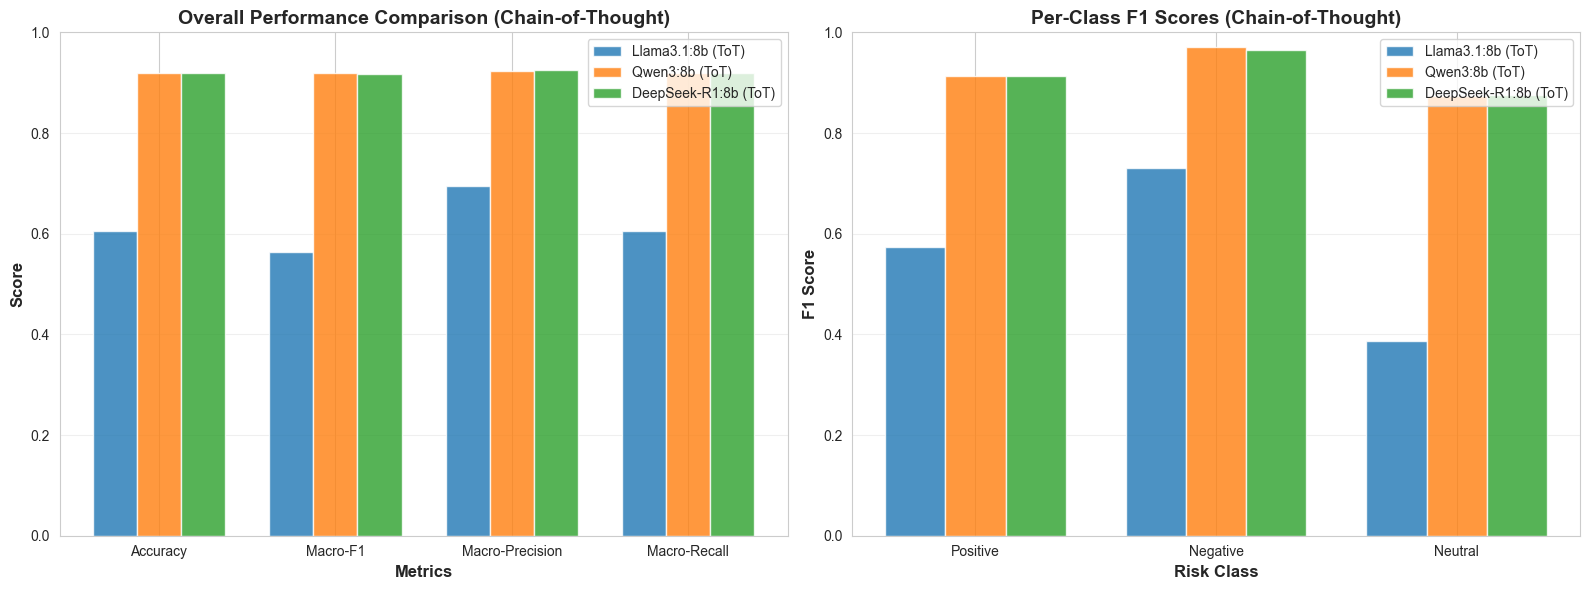

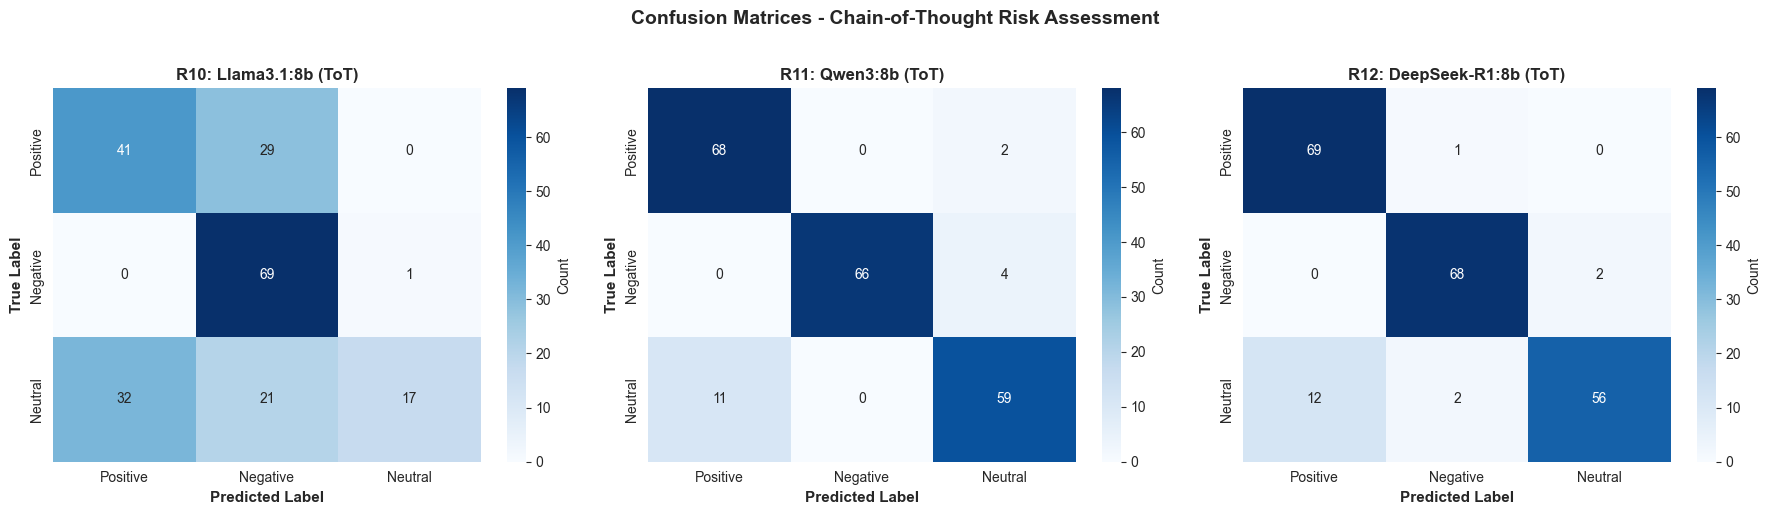

In [18]:
# Performance comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics
metrics_to_plot = ["Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (metrics, label) in enumerate(
    [
        (r10_metrics, "Llama3.1:8b (ToT)"),
        (r11_metrics, "Qwen3:8b (ToT)"),
        (r12_metrics, "DeepSeek-R1:8b (ToT)"),
    ]
):
    values = [np.nan_to_num(metrics.get(m, 0.0)) for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=label, alpha=0.8)

axes[0].set_xlabel("Metrics", fontsize=12, weight="bold")
axes[0].set_ylabel("Score", fontsize=12, weight="bold")
axes[0].set_title(
    "Overall Performance Comparison (Chain-of-Thought)", fontsize=14, weight="bold"
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

# Per-class F1 scores
classes = ["Positive", "Negative", "Neutral"]
x2 = np.arange(len(classes))

for i, (metrics, label) in enumerate(
    [
        (r10_metrics, "Llama3.1:8b (ToT)"),
        (r11_metrics, "Qwen3:8b (ToT)"),
        (r12_metrics, "DeepSeek-R1:8b (ToT)"),
    ]
):
    values = [metrics[f"{c}_F1"] for c in classes]
    axes[1].bar(x2 + i * width, values, width, label=label, alpha=0.8)

axes[1].set_xlabel("Risk Class", fontsize=12, weight="bold")
axes[1].set_ylabel("F1 Score", fontsize=12, weight="bold")
axes[1].set_title("Per-Class F1 Scores (Chain-of-Thought)", fontsize=14, weight="bold")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tot_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Positive", "Negative", "Neutral"]

for idx, (cm, title) in enumerate(
    [
        (r10_cm, "R10: Llama3.1:8b (ToT)"),
        (r11_cm, "R11: Qwen3:8b (ToT)"),
        (r12_cm, "R12: DeepSeek-R1:8b (ToT)"),
    ]
):
    sns.heatmap(
        cm,
        annot=True,
        
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
        cbar_kws={"label": "Count"},
    )
    axes[idx].set_title(title, fontsize=12, weight="bold")
    axes[idx].set_ylabel("True Label", fontsize=11, weight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=11, weight="bold")

plt.suptitle(
    "Confusion Matrices - Chain-of-Thought Risk Assessment",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Save Results

In [19]:
# Save detailed results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

r10_df.to_csv(f"r10_llama3.1_8b_ToT_{timestamp}.csv", index=False)
r11_df.to_csv(f"r11_qwen3_8b_ToT_{timestamp}.csv", index=False)
r12_df.to_csv(f"r12_deepseek_r1_8b_ToT_{timestamp}.csv", index=False)

# Save metrics summary
metrics_df.to_csv(f"tot_metrics_summary_{timestamp}.csv", index=False)

print(f"\n✓ Chain-of-Thought results saved with timestamp: {timestamp}")
print("\nFiles created:")
print(f"  - r10_llama3.1_8b_ToT_{timestamp}.csv")
print(f"  - r11_qwen3_8b_ToT_{timestamp}.csv")
print(f"  - r12_deepseek_r1_8b_ToT_{timestamp}.csv")
print(f"  - ToT_metrics_summary_{timestamp}.csv")
print(f"  - ToT_performance_comparison.png")
print(f"  - ToT_confusion_matrices.png")


✓ Chain-of-Thought results saved with timestamp: 20260225_184058

Files created:
  - r10_llama3.1_8b_ToT_20260225_184058.csv
  - r11_qwen3_8b_ToT_20260225_184058.csv
  - r12_deepseek_r1_8b_ToT_20260225_184058.csv
  - ToT_metrics_summary_20260225_184058.csv
  - ToT_performance_comparison.png
  - ToT_confusion_matrices.png


## 8. Error Analysis

In [20]:
# Error Analysis: Most Common Misclassifications
print("=" * 80)
print("ERROR ANALYSIS: CHAIN-OF-THOUGHT MISCLASSIFICATION PATTERNS")
print("=" * 80)

for df_result, exp_name in [
    (r10_valid, "R10: Llama3.1:8b"),
    (r11_valid, "R11: Qwen3:8b"),
    (r12_valid, "R12: DeepSeek-R1:8b"),
]:
    print(f"\n{exp_name}")
    print("-" * 80)

    # Identify errors
    errors = df_result[df_result["true_risk"] != df_result["predicted_risk"]]

    # Count error types
    error_types = (
        errors.groupby(["true_risk", "predicted_risk"])
        .size()
        .reset_index(name="count")
    )
    error_types = error_types.sort_values("count", ascending=False)

    print(
        f"\nTotal Errors: {len(errors)} / {len(df_result)} ({len(errors) / len(df_result) * 100:.2f}%)"
    )
    print("\nMost Common Error Types:")
    display(error_types.head(5))

    # Show examples of worst errors (high confidence, wrong prediction)
    if len(errors) > 0:
        worst_errors = errors.nlargest(3, "confidence")
        print(f"\nTop 3 High-Confidence Errors:")
        for idx, row in worst_errors.iterrows():
            print(
                f"\n  True: {row['true_risk']} | Predicted: {row['predicted_risk']} | Conf: {row['confidence']:.2f}"
            )
            print(f"  Sentence: {row['sentence'][:120]}...")
            print(f"  Rationale: {row['rationale']}")

# Class-wise Performance Comparison
print("\n" + "=" * 80)
print("CLASS-WISE PERFORMANCE BREAKDOWN")
print("=" * 80)

class_comparison = []
for metrics, model_name in [
    (r10_metrics, "Llama3.1:8b"),
    (r11_metrics, "Qwen3:8b"),
    (r12_metrics, "DeepSeek-R1:8b"),
]:
    for risk in ["Positive", "Negative", "Neutral"]:
        class_comparison.append(
            {
                "Model": model_name,
                "Class": risk,
                "Precision": metrics[f"{risk}_Precision"],
                "Recall": metrics[f"{risk}_Recall"],
                "F1-Score": metrics[f"{risk}_F1"],
            }
        )

class_df = pd.DataFrame(class_comparison)

# Pivot for better visualization
for metric in ["Precision", "Recall", "F1-Score"]:
    print(f"\n{metric} by Class:")
    pivot = class_df.pivot(index="Class", columns="Model", values=metric)
    display(pivot.round(4))

print("\n" + "=" * 80)
print("COMPREHENSIVE METRICS TABLE")
print("=" * 80)
display(metrics_df.round(4))

ERROR ANALYSIS: CHAIN-OF-THOUGHT MISCLASSIFICATION PATTERNS

R10: Llama3.1:8b
--------------------------------------------------------------------------------

Total Errors: 83 / 210 (39.52%)

Most Common Error Types:


,true_risk,predicted_risk,count
2,neutral,positive,32
3,positive,negative,29
1,neutral,negative,21
0,negative,neutral,1



Top 3 High-Confidence Errors:

  True: neutral | Predicted: positive | Conf: 0.90
  Sentence: 3 January 2011 - Scandinavian lenders Sampo Bank ( HEL : SAMAS ) , Pohjola Bank ( HEL : POH1S ) and Svenska Handelsbanke...
  Rationale: The fact that Scandinavian lenders have provided a significant line of credit to Lemminkainen Oyj suggests that they are confident in the company's ability to repay the loan and use it for growth initiatives, which is a positive signal from an investor's perspective.

  True: neutral | Predicted: positive | Conf: 0.85
  Sentence: The company is owned by the State of Finland and the European Aeronautic Defense and Space Company EADS N.V. Tekla is an...
  Rationale: The statement indicates that Tekla is an international software company with a strong ownership structure, implying stability and potential for growth. The mention of providing solutions for various industries suggests a diversified revenue stream, which reduces risk. Additionally, the fact that it

,true_risk,predicted_risk,count
1,neutral,positive,11
0,negative,neutral,4
2,positive,neutral,2



Top 3 High-Confidence Errors:

  True: neutral | Predicted: positive | Conf: 0.95
  Sentence: Our customers come from the following countries : UK , USA , Spain , France , Italy , Germany , China , Sweden , Norway ...
  Rationale: The statement provides information about geographic diversification of customer bases across 30+ countries, which reduces concentration risk and aligns with market expansion opportunities. While not explicitly stating revenue growth or profit increases, the broad customer distribution inherently signals reduced vulnerability to regional economic downturns, supporting the positive hypothesis over neutral or negative interpretations.

  True: neutral | Predicted: positive | Conf: 0.95
  Sentence: Metsa-Botnia will finance the payment of dividends , the repayment of capital and the repurchase of its own shares with ...
  Rationale: The statement indicates effective financial management and strategic use of available resources. Divesting underperforming assets (

...

Model,DeepSeek-R1:8b,Llama3.1:8b,Qwen3:8b
Class,,,
Negative,0.9714,0.9857,0.9429
Neutral,0.8000,0.2429,0.8429
Positive,0.9857,0.5857,0.9714



F1-Score by Class:


Model,DeepSeek-R1:8b,Llama3.1:8b,Qwen3:8b
Class,,,
Negative,0.9645,0.7302,0.9706
Neutral,0.8750,0.3864,0.8741
Positive,0.9139,0.5734,0.9128



COMPREHENSIVE METRICS TABLE


,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,R10: Llama3.1:8b (ToT),210,210,0.6048,0.5633,0.5633,0.6953,0.6048,0.4480,0.5616,0.5857,0.5734,0.5798,0.9857,0.7302,0.9444,0.2429,0.3864
1,R11: Qwen3:8b (ToT),210,210,0.9190,0.9191,0.9191,0.9228,0.9190,0.8804,0.8608,0.9714,0.9128,1.0000,0.9429,0.9706,0.9077,0.8429,0.8741
2,R12: DeepSeek-R1:8b (ToT),210,210,0.9190,0.9178,0.9178,0.9250,0.9190,0.8826,0.8519,0.9857,0.9139,0.9577,0.9714,0.9645,0.9655,0.8000,0.8750


## 10. Confidence Calibration Analysis

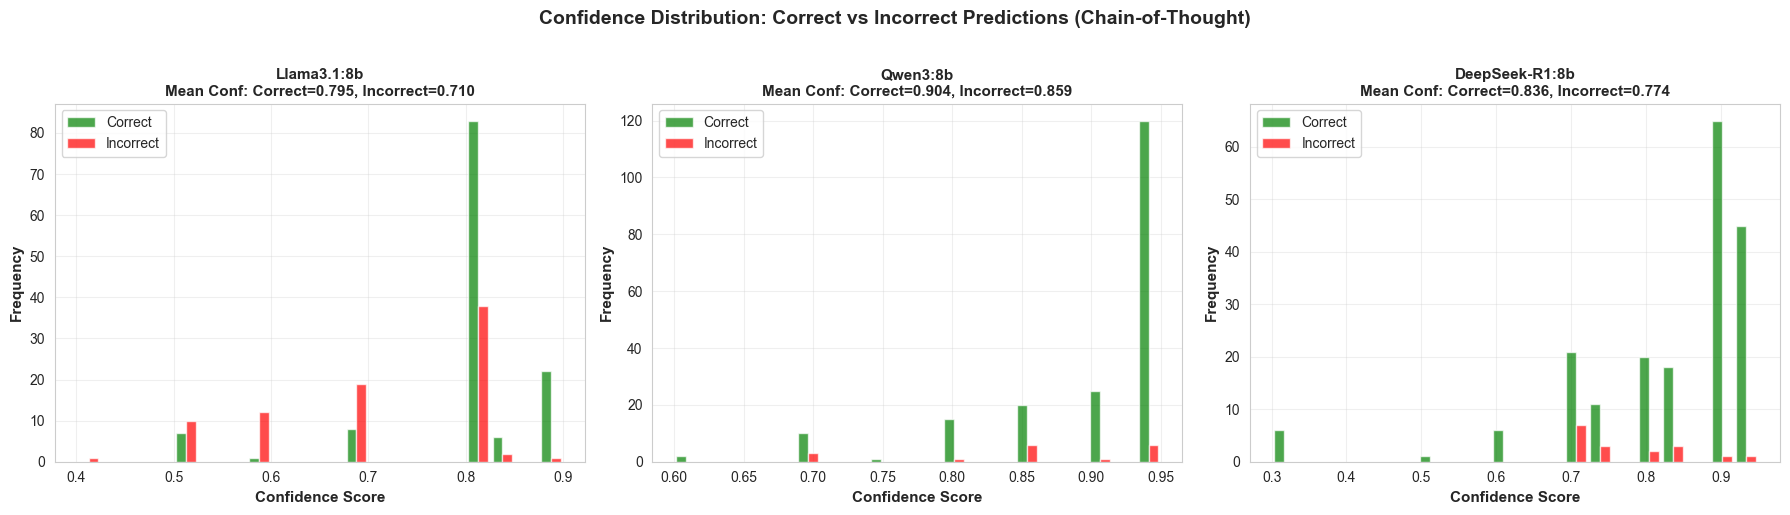


CONFIDENCE CALIBRATION ANALYSIS

R10: Llama3.1:8b:
  Average Confidence (Correct): 0.7953
  Average Confidence (Incorrect): 0.7096
  Calibration Gap: 0.0856
  Total Correct: 127 / 210

  Confidence by Predicted Class:
    Positive: 0.7849 (n=73)
    Negative: 0.7416 (n=119)
    Neutral: 0.7972 (n=18)

R11: Qwen3:8b:
  Average Confidence (Correct): 0.9039
  Average Confidence (Incorrect): 0.8588
  Calibration Gap: 0.0451
  Total Correct: 193 / 210

  Confidence by Predicted Class:
    Positive: 0.9108 (n=79)
    Negative: 0.9174 (n=66)
    Neutral: 0.8700 (n=65)

R12: DeepSeek-R1:8b:
  Average Confidence (Correct): 0.8363
  Average Confidence (Incorrect): 0.7735
  Calibration Gap: 0.0627
  Total Correct: 193 / 210

  Confidence by Predicted Class:
    Positive: 0.8333 (n=81)
    Negative: 0.8669 (n=71)
    Neutral: 0.7845 (n=58)


In [21]:
# Confidence Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df_result, title) in enumerate(
    [(r10_valid, "Llama3.1:8b"), (r11_valid, "Qwen3:8b"), (r12_valid, "DeepSeek-R1:8b")]
):
    df_result["correct"] = (
        df_result["true_risk"] == df_result["predicted_risk"]
    )

    correct_conf = df_result[df_result["correct"]]["confidence"]
    incorrect_conf = df_result[~df_result["correct"]]["confidence"]

    axes[idx].hist(
        [correct_conf, incorrect_conf],
        bins=20,
        label=["Correct", "Incorrect"],
        alpha=0.7,
        color=["green", "red"],
    )
    axes[idx].set_xlabel("Confidence Score", fontsize=11, weight="bold")
    axes[idx].set_ylabel("Frequency", fontsize=11, weight="bold")
    axes[idx].set_title(
        f"{title}\nMean Conf: Correct={correct_conf.mean():.3f}, Incorrect={incorrect_conf.mean():.3f}",
        fontsize=11,
        weight="bold",
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle(
    "Confidence Distribution: Correct vs Incorrect Predictions (Chain-of-Thought)",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confidence_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("CONFIDENCE CALIBRATION ANALYSIS")
print("=" * 80)
for df_result, exp_name in [
    (r10_valid, "R10: Llama3.1:8b"),
    (r11_valid, "R11: Qwen3:8b"),
    (r12_valid, "R12: DeepSeek-R1:8b"),
]:
    df_result["correct"] = (
        df_result["true_risk"] == df_result["predicted_risk"]
    )

    avg_conf_correct = df_result[df_result["correct"]]["confidence"].mean()
    avg_conf_incorrect = df_result[~df_result["correct"]]["confidence"].mean()
    calibration_gap = avg_conf_correct - avg_conf_incorrect

    print(f"\n{exp_name}:")
    print(f"  Average Confidence (Correct): {avg_conf_correct:.4f}")
    print(f"  Average Confidence (Incorrect): {avg_conf_incorrect:.4f}")
    print(f"  Calibration Gap: {calibration_gap:.4f}")
    print(f"  Total Correct: {df_result['correct'].sum()} / {len(df_result)}")

    # Confidence by risk class
    print(f"\n  Confidence by Predicted Class:")
    for risk in ["positive", "negative", "neutral"]:
        class_df = df_result[df_result["predicted_risk"] == risk]
        if len(class_df) > 0:
            print(
                f"    {risk.capitalize()}: {class_df['confidence'].mean():.4f} (n={len(class_df)})"
            )

## 11. Classification Reports with Per-Class Metrics

In [22]:
# Detailed Classification Reports
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for df_result, exp_name in [
    (r10_valid, "R10: Llama3.1:8b"),
    (r11_valid, "R11: Qwen3:8b"),
    (r12_valid, "R12: DeepSeek-R1:8b"),
]:
    print("\n" + "=" * 80)
    print(f"{exp_name}")
    print("=" * 80)
    print(
        classification_report(
            df_result["true_risk"],
            df_result["predicted_risk"],
            labels=["positive", "negative", "neutral"],
            target_names=["Positive", "Negative", "Neutral"],
        )
    )

# Class-wise Metrics Summary Table
print("\n" + "=" * 80)
print("CLASS-WISE METRICS SUMMARY")
print("=" * 80)

summary_data = []
for metrics, model in [
    (r10_metrics, "Llama3.1:8b"),
    (r11_metrics, "Qwen3:8b"),
    (r12_metrics, "DeepSeek-R1:8b"),
]:
    summary_data.append(
        {
            "Model": model,
            "Pos_P": metrics["Positive_Precision"],
            "Pos_R": metrics["Positive_Recall"],
            "Pos_F1": metrics["Positive_F1"],
            "Neg_P": metrics["Negative_Precision"],
            "Neg_R": metrics["Negative_Recall"],
            "Neg_F1": metrics["Negative_F1"],
            "Neu_P": metrics["Neutral_Precision"],
            "Neu_R": metrics["Neutral_Recall"],
            "Neu_F1": metrics["Neutral_F1"],
        }
    )

summary_df = pd.DataFrame(summary_data)
print("\nPer-Class Metrics (P=Precision, R=Recall, F1=F1-Score):")
display(summary_df.round(4))


DETAILED CLASSIFICATION REPORTS

R10: Llama3.1:8b
              precision    recall  f1-score   support

    Positive       0.56      0.59      0.57        70
    Negative       0.58      0.99      0.73        70
     Neutral       0.94      0.24      0.39        70

    accuracy                           0.60       210
   macro avg       0.70      0.60      0.56       210
weighted avg       0.70      0.60      0.56       210


R11: Qwen3:8b
              precision    recall  f1-score   support

    Positive       0.86      0.97      0.91        70
    Negative       1.00      0.94      0.97        70
     Neutral       0.91      0.84      0.87        70

    accuracy                           0.92       210
   macro avg       0.92      0.92      0.92       210
weighted avg       0.92      0.92      0.92       210


R12: DeepSeek-R1:8b
              precision    recall  f1-score   support

    Positive       0.85      0.99      0.91        70
    Negative       0.96      0.97      0.9

,Model,Pos_P,Pos_R,Pos_F1,Neg_P,Neg_R,Neg_F1,Neu_P,Neu_R,Neu_F1
0,Llama3.1:8b,0.5616,0.5857,0.5734,0.5798,0.9857,0.7302,0.9444,0.2429,0.3864
1,Qwen3:8b,0.8608,0.9714,0.9128,1.0000,0.9429,0.9706,0.9077,0.8429,0.8741
2,DeepSeek-R1:8b,0.8519,0.9857,0.9139,0.9577,0.9714,0.9645,0.9655,0.8000,0.8750


## 12. ToT vs CoT vs Few-Shot vs Zero-Shot Comparison

In [23]:
import glob
# Load previous approach metrics for comparison
try:
    # Find the most recent metrics files
    zero_shot_files = sorted(glob.glob("../Zero_Shot/zero_shot_metrics_summary_*.csv"))
    few_shot_files = sorted(glob.glob("../Few_Shot/few_shot_risk_metrics_summary_*.csv"))
    cot_files = sorted(glob.glob("../Chain_of_Thought/cot_metrics_summary_*.csv"))

    zero_shot_metrics = pd.read_csv(zero_shot_files[-1]) if zero_shot_files else None
    few_shot_metrics = pd.read_csv(few_shot_files[-1]) if few_shot_files else None
    cot_metrics = pd.read_csv(cot_files[-1]) if cot_files else None

    if zero_shot_metrics is not None:
        print(f"✓ Loaded Zero-Shot metrics from: {zero_shot_files[-1]}")
    if few_shot_metrics is not None:
        print(f"✓ Loaded Few-Shot metrics from: {few_shot_files[-1]}")
    if cot_metrics is not None:
        print(f"✓ Loaded CoT metrics from: {cot_files[-1]}")

except Exception as e:
    print(f"⚠️ Could not load comparison metrics: {e}")
    zero_shot_metrics = None
    few_shot_metrics = None
    cot_metrics = None

✓ Loaded Zero-Shot metrics from: ../Zero_Shot/zero_shot_metrics_summary_20260224_005638.csv
✓ Loaded Few-Shot metrics from: ../Few_Shot/few_shot_risk_metrics_summary_20260224_142800.csv
✓ Loaded CoT metrics from: ../Chain_of_Thought/cot_metrics_summary_20260225_122843.csv



CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT


,Approach,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,Zero-Shot,R1: llama3.1:8b (Zero-Shot),210,210,0.8048,0.7874,0.7874,0.8524,0.8048,0.7368,0.8571,0.9429,0.8980,0.7000,1.0000,0.8235,1.0000,0.4714,0.6408
1,Zero-Shot,R2: qwen3:8b (Zero-Shot),210,210,0.8667,0.8632,0.8632,0.8851,0.8667,0.8124,0.7500,0.9857,0.8519,0.9853,0.9571,0.9710,0.9200,0.6571,0.7667
2,Zero-Shot,R3: deepseek-r1:8b (Zero-Shot),210,210,0.8714,0.8653,0.8653,0.8993,0.8714,0.8243,0.7527,1.0000,0.8589,0.9452,0.9857,0.9650,1.0000,0.6286,0.7719
3,Few-Shot,R4: Llama3.1:8b (Few-Shot),210,210,0.8286,0.8230,0.8230,0.8575,0.8286,0.7593,0.8611,0.8857,0.8732,0.7340,0.9857,0.8415,0.9773,0.6143,0.7544
4,Few-Shot,R5: Qwen3:8b (Few-Shot),210,210,0.9286,0.9292,0.9292,0.9324,0.9286,0.8940,0.9306,0.9571,0.9437,1.0000,0.9000,0.9474,0.8667,0.9286,0.8966
5,Few-Shot,R6: DeepSeek-R1:8b (Few-Shot),210,210,0.9238,0.9239,0.9239,0.9247,0.9238,0.8861,0.8919,0.9429,0.9167,0.9853,0.9571,0.9710,0.8971,0.8714,0.8841
6,Chain-of-Thought,R7: Llama3.1:8b (CoT),210,210,0.7571,0.7296,0.7296,0.8318,0.7571,0.6802,0.8649,0.9143,0.8889,0.6306,1.0000,0.7735,1.0000,0.3571,0.5263
7,Chain-of-Thought,R8: Qwen3:8b (CoT),210,210,0.9381,0.9380,0.9380,0.9391,0.9381,0.9077,0.9067,0.9714,0.9379,0.9853,0.9571,0.9710,0.9254,0.8857,0.9051
8,Chain-of-Thought,R9: DeepSeek-R1:8b (CoT),210,210,0.9190,0.9187,0.9187,0.9244,0.9190,0.8816,0.8375,0.9571,0.8933,0.9857,0.9857,0.9857,0.9500,0.8143,0.8769
9,Tree-of-Thought,R10: Llama3.1:8b (ToT),210,210,0.6048,0.5633,0.5633,0.6953,0.6048,0.4480,0.5616,0.5857,0.5734,0.5798,0.9857,0.7302,0.9444,0.2429,0.3864



✓ Full comparison table saved as: all_approaches_comparison_20260225_184058.csv

AVERAGE PERFORMANCE BY APPROACH


,Accuracy,Macro-F1,MCC
Approach,,,
Chain-of-Thought,0.8714,0.8621,0.8232
Few-Shot,0.8937,0.8920,0.8465
Tree-of-Thought,0.8143,0.8001,0.7370
Zero-Shot,0.8476,0.8386,0.7912


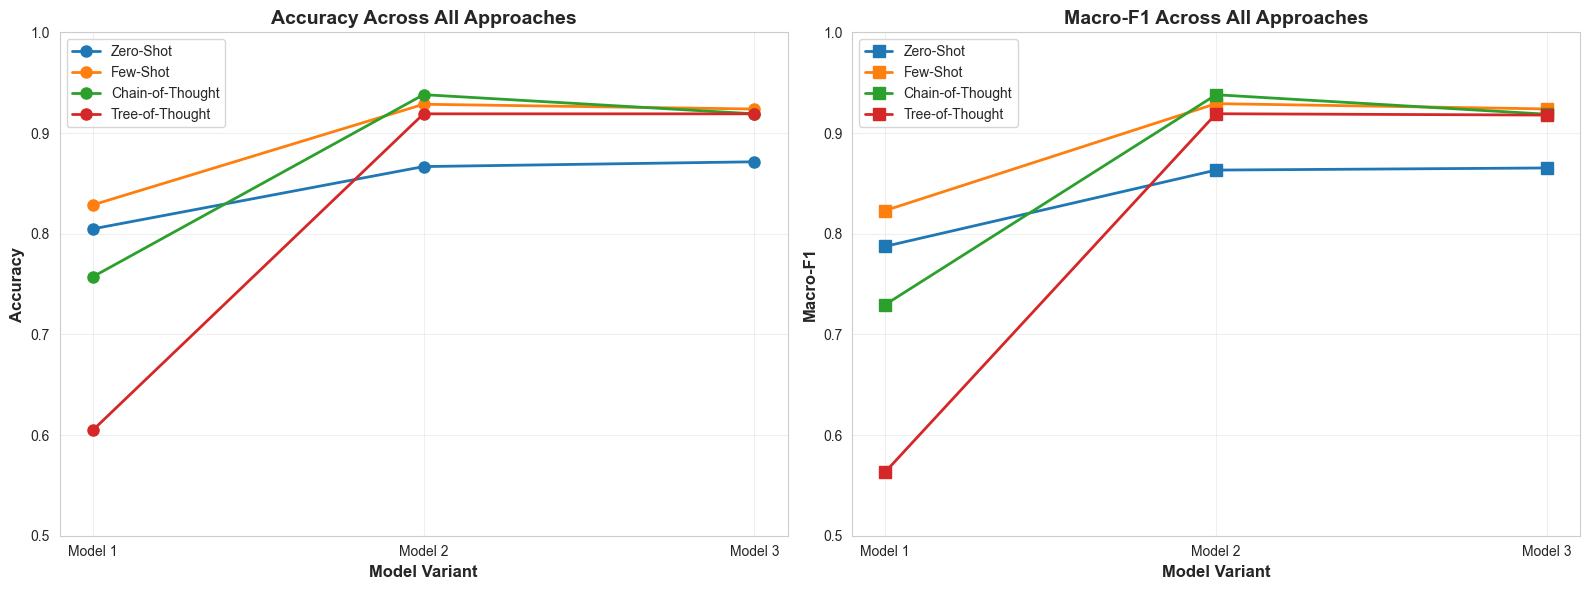

✓ Complete approach comparison visualization saved


In [24]:
# Compare all four approaches
if all(m is not None for m in [zero_shot_metrics, few_shot_metrics, cot_metrics]):
    all_approaches = pd.concat(
        [
            zero_shot_metrics.assign(Approach="Zero-Shot"),
            few_shot_metrics.assign(Approach="Few-Shot"),
            cot_metrics.assign(Approach="Chain-of-Thought"),
            metrics_df.assign(Approach="Tree-of-Thought"),
        ],
        ignore_index=True,
    )

    print("\n" + "=" * 80)
    print("CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT")
    print("=" * 80)

    
    comparison_cols = ["Approach", "Experiment", "Accuracy", "Macro-F1", "MCC"]
    if all(col in all_approaches.columns for col in comparison_cols):
        display(all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1']].round(4))
        #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
    else:
        display(
            all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1' ]].round(4))
       #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
        

    print("\n" + "=" * 80)
    print("AVERAGE PERFORMANCE BY APPROACH")
    print("=" * 80)

    approach_avg = all_approaches.groupby("Approach")[["Accuracy", "Macro-F1"]].mean()
    if "MCC" in all_approaches.columns:
        approach_avg["MCC"] = all_approaches.groupby("Approach")["MCC"].mean()

    display(approach_avg.round(4))

    # Visualize approach progression
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[0].plot(
            range(len(approach_data)),
            approach_data["Accuracy"],
            marker="o",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[0].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[0].set_ylabel("Accuracy", fontsize=12, weight="bold")
    axes[0].set_title("Accuracy Across All Approaches", fontsize=14, weight="bold")
    axes[0].set_xticks(range(3))
    axes[0].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0.5, 1.0])

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[1].plot(
            range(len(approach_data)),
            approach_data["Macro-F1"],
            marker="s",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[1].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[1].set_ylabel("Macro-F1", fontsize=12, weight="bold")
    axes[1].set_title("Macro-F1 Across All Approaches", fontsize=14, weight="bold")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])

    plt.tight_layout()
    plt.savefig(
        "all_approaches_comparison_risk_assessment.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("✓ Complete approach comparison visualization saved")
else:
    print("\n⚠️ Cannot perform full comparison - missing baseline metrics")
    print(
        "   Please run Zero-Shot (R1-R3), Few-Shot (R4-R6), and CoT (R7-R9) experiments first"
    )